# Stage 6 — Scoring, Ranking, and Statistical Testing

Transforms the per-run CSVs from Stages 3-5 into thesis-ready summary tables
and significance tests. This stage is read-only against `./results/`.

## What this stage produces
- Mean ± std rankings for NLP models (by F1) and regression models (by R²).
- A one-way ANOVA on NLP F1 with Tukey HSD post-hoc pairwise comparisons.
- A 1×3 diagnostic figure (`results/nlp_f1_diagnostics.png`).
- A baseline-vs-+NLP uplift table for every regressor.

## What this stage consumes
- `./results/nlp_results.csv` (Stage 3).
- `./results/regression_results.csv` (Stage 4).

## Composite scoring (TODO)
The thesis frames evaluation as `accuracy − λ · energy`, with three
λ regimes from `CONFIG["lambda_scenarios"]`:
research (`λ=10`), moderate (`λ=1_000`), production (`λ=100_000`).
The composite score is **not yet computed here** — it depends on the
`energy_*_kwh` columns produced by the external energy join, which runs
downstream of this notebook. Once those columns are present in the CSVs,
the same `score_and_rank` aggregation can be reused with `accuracy_col`
swapped for the composite. This is the planned next iteration.


In [1]:
# Shared paths/config plus pandas/numpy imports from common.py.
from common import *

# Plotting and statistical testing libraries used in this stage.
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Apply a clean plotting theme for all diagnostic charts.
sns.set_theme(style="whitegrid")

# Load run-level metrics produced by earlier stages.
nlp_df = pd.read_csv(RESULTS_DIR / "nlp_results_with_energy.csv")
reg_df = pd.read_csv(RESULTS_DIR / "regression_results_with_energy.csv")
print(f"Loaded {len(nlp_df)} NLP rows, {len(reg_df)} regression rows")

[common] device=cpu  artifacts=/cluster/tufts/hrilab/jmonta04/modular_pipeline/artifacts  results=/cluster/tufts/hrilab/jmonta04/modular_pipeline/results


Loaded 40 NLP rows, 140 regression rows


## 6.1 Aggregate and rank

In [2]:
def score_and_rank(df, accuracy_col):
    """Aggregate accuracy and timing across seeds, then rank models."""
    # Aggregating across seeds (10 per model) gives mean ± std, which is the
    # standard reproducibility-disclosure convention for ML evaluation: a
    # single seed could win or lose by luck, but the mean over 10 seeds with
    # a tight std band is a meaningful claim. Stages 3 and 4 are already
    # structured to produce 10 seeds per (model, variant) so this groupby
    # always sees a uniform sample size per group.
    agg = df.groupby("model").agg(
        accuracy_mean=(accuracy_col, "mean"),
        accuracy_std=(accuracy_col, "std"),
        train_time_mean=("train_time_s", "mean"),
        infer_time_mean=("infer_time_s", "mean"),
    ).reset_index()
    return agg


nlp_scores = score_and_rank(nlp_df, "f1")
print("=== NLP Model Rankings ===")
display(nlp_scores.sort_values("accuracy_mean", ascending=False).round(6))

reg_scores = score_and_rank(reg_df, "r2")
print("\n=== Regression Model Rankings (baseline + NLP-augmented) ===")
display(reg_scores.sort_values("accuracy_mean", ascending=False).round(6))

=== NLP Model Rankings ===


,model,accuracy_mean,accuracy_std,train_time_mean,infer_time_mean
1,DistilBERT,0.335343,0.020329,25.626637,0.491897
2,FinBERT,0.329128,0.017701,46.730210,0.997296
0,BERT-base,0.327169,0.026732,46.035736,0.863515
3,RoBERTa-base,0.277298,0.009034,48.964258,0.917666



=== Regression Model Rankings (baseline + NLP-augmented) ===


,model,accuracy_mean,accuracy_std,train_time_mean,infer_time_mean
3,Elastic Net +NLP,-0.000309,0.000000,0.000740,0.000095
2,Elastic Net,-0.000309,0.000000,0.000664,0.000090
4,Lasso,-0.000309,0.000000,0.001254,0.000066
5,Lasso +NLP,-0.000309,0.000000,0.000468,0.000065
11,Ridge +NLP,-0.008100,0.000000,0.000336,0.000045
9,Linear Regression +NLP,-0.008339,0.000000,0.000427,0.000046
10,Ridge,-0.013013,0.000000,0.000332,0.000045
8,Linear Regression,-0.013099,0.000000,0.000392,0.000049
12,XGBoost,-0.133071,0.000000,0.053403,0.000706
1,CatBoost +NLP,-0.137334,0.096689,0.054675,0.000331


## 6.2 ANOVA + Tukey HSD on NLP F1

In [3]:
# model_order fixes display/statistics order across outputs.
model_order = sorted(nlp_df["model"].unique())
# groups is one F1-score array per model for ANOVA/Tukey testing.
groups = [nlp_df.loc[nlp_df["model"] == m, "f1"].values for m in model_order]

# One-way ANOVA tests the null hypothesis that all model means are equal,
# i.e., that observed differences in mean F1 between DistilBERT, BERT-base,
# RoBERTa-base, and FinBERT are noise from seed-level variation. The
# F-statistic is the ratio of between-model variance to within-model
# (across-seed) variance: F >> 1 means between-model differences dwarf
# seed noise. The p-value is the probability of seeing an F this large
# under the null; p < 0.05 lets us reject "all models perform equally".
# Note: ANOVA only tells us SOMETHING differs — not WHICH pair differs.
anova_result = stats.f_oneway(*groups)
print("=== One-way ANOVA on NLP F1 ===")
print(f"F-statistic: {anova_result.statistic:.6f}")
print(f"p-value:     {anova_result.pvalue:.6e}")

try:
    # Tukey HSD ("Honestly Significant Difference") is the standard post-hoc
    # follow-up to a significant ANOVA: once ANOVA tells us at least one
    # pair of models differs, Tukey identifies WHICH pairs while controlling
    # the family-wise error rate across all C(n,2) comparisons. The result
    # is a square matrix of pairwise p-values; cell (i, j) is the probability
    # that models i and j have the same true mean F1. Small values (e.g., < 0.05)
    # indicate the pair differs significantly even after correcting for the
    # number of comparisons being made.
    tukey_result = stats.tukey_hsd(*groups)
    tukey_pvalues = pd.DataFrame(
        tukey_result.pvalue, index=model_order, columns=model_order
    )
    print("\n=== Tukey HSD pairwise p-values ===")
    display(tukey_pvalues.round(6))
except Exception as e:
    tukey_pvalues = None
    print(f"\nTukey HSD unavailable in this scipy version: {e}")

=== One-way ANOVA on NLP F1 ===
F-statistic: 18.938389
p-value:     1.533824e-07



=== Tukey HSD pairwise p-values ===


,BERT-base,DistilBERT,FinBERT,RoBERTa-base
BERT-base,1.000000,0.785410,0.995937,0.000010
DistilBERT,0.785410,1.000000,0.891590,0.000001
FinBERT,0.995937,0.891590,1.000000,0.000005
RoBERTa-base,0.000010,0.000001,0.000005,1.000000


## 6.3 Diagnostic plots

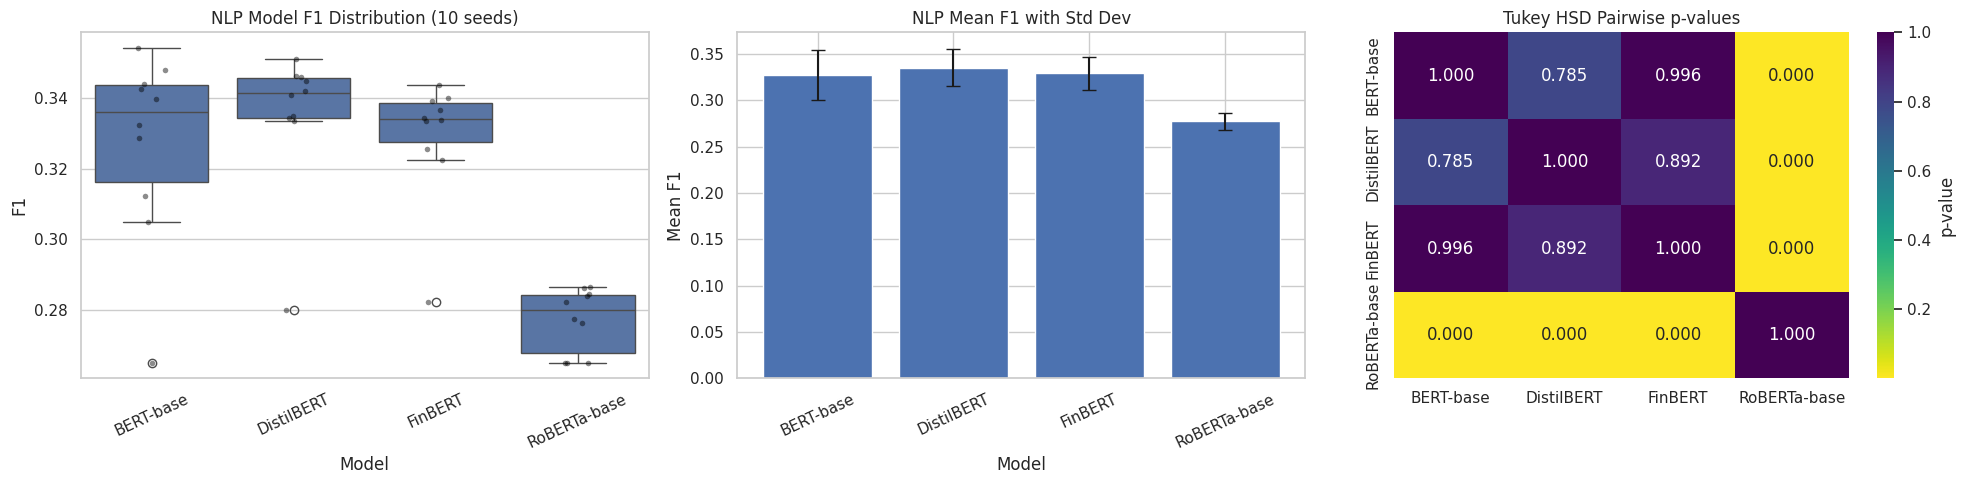

In [4]:
# Three diagnostics in one figure:
#   - Left: per-seed F1 distribution per model, so the reader can see how
#     spread the seed-level results are (a tall box = unstable; a tight box
#     = robust).
#   - Middle: mean ± std bar chart, the headline summary number per model.
#   - Right: Tukey HSD pairwise p-value heatmap. Dark cells = significantly
#     different pairs; light cells = statistical ties.
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Per-seed F1 distribution
sns.boxplot(data=nlp_df, x="model", y="f1", order=model_order, ax=axes[0])
sns.stripplot(data=nlp_df, x="model", y="f1", order=model_order,
              color="black", alpha=0.45, size=4, ax=axes[0])
axes[0].set_title(f"NLP Model F1 Distribution ({nlp_df['seed'].nunique()} seeds)")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("F1")
axes[0].tick_params(axis="x", rotation=25)

# 2) Mean ± std bar chart
nlp_summary = nlp_df.groupby("model")["f1"].agg(["mean", "std"]).reindex(model_order)
axes[1].bar(nlp_summary.index, nlp_summary["mean"],
            yerr=nlp_summary["std"], capsize=5)
axes[1].set_title("NLP Mean F1 with Std Dev")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Mean F1")
axes[1].tick_params(axis="x", rotation=25)

# 3) Tukey HSD p-value heatmap
if tukey_pvalues is not None:
    sns.heatmap(
        tukey_pvalues.loc[model_order, model_order],
        annot=True, fmt=".3f", cmap="viridis_r",
        cbar_kws={"label": "p-value"},
        ax=axes[2],
    )
    axes[2].set_title("Tukey HSD Pairwise p-values")
else:
    axes[2].text(0.5, 0.5, "Tukey HSD unavailable", ha="center", va="center")
    axes[2].set_axis_off()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "nlp_f1_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.4 Regression uplift table (baseline vs +NLP)

In [5]:
# Uplift table: the thesis's headline regression result. We average R²
# across seeds for each (model, variant) and subtract baseline from
# augmented to get `delta`:
#   delta > 0  =>  rolling NLP sentiment helped that regressor on AMZN
#   delta < 0  =>  rolling NLP sentiment hurt (likely overfitting the
#                  small post-2020 segment with noisy weak labels)
# Mean over seeds is the right summary because each seed yields a noisy
# point estimate and we want the systematic component of the effect.
baseline_r2 = (
    reg_df[~reg_df["model"].str.endswith("+NLP")]
    .groupby("model")["r2"]
    .mean()
    .rename("baseline_r2")
)

augmented_r2 = (
    reg_df[reg_df["model"].str.endswith("+NLP")]
    .assign(base_model=lambda frame: frame["model"].str.replace(" +NLP", "", regex=False))
    .groupby("base_model")["r2"]
    .mean()
    .rename("augmented_r2")
)

uplift_table = pd.concat([baseline_r2, augmented_r2], axis=1)
uplift_table["delta"] = uplift_table["augmented_r2"] - uplift_table["baseline_r2"]

print("=== Regression uplift from real NLP features (mean over seeds) ===")
display(uplift_table.sort_values("delta", ascending=False).round(6))

=== Regression uplift from real NLP features (mean over seeds) ===


,baseline_r2,augmented_r2,delta
CatBoost,-0.197143,-0.137334,0.059810
Ridge,-0.013013,-0.008100,0.004914
Linear Regression,-0.013099,-0.008339,0.004760
Lasso,-0.000309,-0.000309,0.000000
Elastic Net,-0.000309,-0.000309,0.000000
LightGBM,-0.980772,-1.211791,-0.231019
XGBoost,-0.133071,-0.384483,-0.251412
